<a href="https://colab.research.google.com/github/Rimshakalhoro/flyrank-ml-internship-rimsha/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rimshakalhoro/flyrank-ml-internship-rimsha/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

The action queue ranks content pages using a decision-support score. Pages near the top of the queue are not automatically changed or refreshed. They are prioritized for human review.

The ranking uses observed signals including search impressions, average position, CTR, content age, time since the last update, and recent trend direction.

Each recommendation includes reason codes so that a human can understand why the page was ranked. For example, a page may be prioritized because it has high impressions but low CTR, has a declining trend, has not been updated recently, or has a weak average position.

The ranking is directional and supports prioritization. It does not prove that refreshing a page will improve its search performance.

In [11]:
# ============================================================
# ML-10 SECTION 1 — RANKED ACTIONS + REASON CODES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/Rimshakalhoro/flyrank-ml-internship-rimsha/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows:", len(df))


# ------------------------------------------------------------
# CREATE HELPFUL FLAGS
# ------------------------------------------------------------

# Only pages with search impressions are considered
df["eligible"] = df["impressions_90d"].fillna(0) > 0

# Median values used as simple reference points
median_ctr = df.loc[df["eligible"], "ctr"].median()
median_age = df["content_age_days"].median()
median_days_since_update = df["days_since_last_update"].median()


# ------------------------------------------------------------
# CREATE ACTION SCORE
# ------------------------------------------------------------

# Start with score = 0
df["action_score"] = 0.0


# High impressions + low CTR
high_impressions_threshold = df["impressions_90d"].median()

high_impressions_low_ctr = (
    (df["impressions_90d"] >= high_impressions_threshold) &
    (df["ctr"] < median_ctr)
)

df.loc[high_impressions_low_ctr, "action_score"] += 3


# Declining trend
declining = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .str.contains("down|declin|negative", na=False)
)

df.loc[declining, "action_score"] += 2


# Older content
old_content = (
    df["content_age_days"] > median_age
)

df.loc[old_content, "action_score"] += 1


# Long time since last update
stale_content = (
    df["days_since_last_update"] > median_days_since_update
)

df.loc[stale_content, "action_score"] += 2


# Weak search position
weak_position = (
    df["avg_position"] > df["avg_position"].median()
)

df.loc[weak_position, "action_score"] += 1


# Only eligible pages should be ranked
df.loc[~df["eligible"], "action_score"] = 0


# ------------------------------------------------------------
# CREATE REASON CODES
# ------------------------------------------------------------

def create_reason_codes(row):

    reasons = []

    if (
        row["impressions_90d"] >= high_impressions_threshold
        and row["ctr"] < median_ctr
    ):
        reasons.append("High impressions but below-median CTR")

    trend_value = str(row["trend_direction"]).lower()

    if (
        "down" in trend_value
        or "declin" in trend_value
        or "negative" in trend_value
    ):
        reasons.append("Declining performance trend")

    if row["content_age_days"] > median_age:
        reasons.append("Older content")

    if row["days_since_last_update"] > median_days_since_update:
        reasons.append("Long time since last update")

    if row["avg_position"] > df["avg_position"].median():
        reasons.append("Below-median search position")

    if len(reasons) == 0:
        return "No strong action signal"

    return "; ".join(reasons)


df["reason_codes"] = df.apply(
    create_reason_codes,
    axis=1
)


# ------------------------------------------------------------
# ASSIGN RECOMMENDED ACTION
# ------------------------------------------------------------

def recommend_action(row):

    if row["action_score"] >= 6:
        return "Priority human review"

    elif row["action_score"] >= 4:
        return "Review for content refresh"

    elif row["action_score"] >= 2:
        return "Monitor and review"

    else:
        return "No immediate action"


df["recommended_action"] = df.apply(
    recommend_action,
    axis=1
)


# ------------------------------------------------------------
# CREATE RANKED QUEUE
# ------------------------------------------------------------

action_queue = (
    df[df["eligible"]]
    .sort_values(
        by=[
            "action_score",
            "impressions_90d"
        ],
        ascending=[
            False,
            False
        ]
    )
    .copy()
)


# Select safe columns
queue_columns = [
    "content_id",
    "content_type",
    "impressions_90d",
    "ctr",
    "avg_position",
    "trend_direction",
    "content_age_days",
    "days_since_last_update",
    "action_score",
    "recommended_action",
    "reason_codes"
]

queue_columns = [
    col for col in queue_columns
    if col in action_queue.columns
]

top_queue = action_queue[
    queue_columns
].head(20)


print("\n" + "=" * 60)
print("TOP 20 CONTENT ACTION QUEUE")
print("=" * 60)

display(top_queue)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\nACTION SUMMARY:")

display(
    action_queue["recommended_action"]
    .value_counts()
    .rename_axis("Recommended action")
    .reset_index(name="Number of pages")
)


Dataset loaded successfully!
Rows: 30000

TOP 20 CONTENT ACTION QUEUE


,content_id,content_type,impressions_90d,ctr,avg_position,trend_direction,content_age_days,days_since_last_update,action_score,recommended_action,reason_codes
22694,content_8b36799b7e44,keyword article,141400,0.02,32.0,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
6689,content_e752a4e03dd3,keyword article,130892,0.01,23.9,down,287,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
3343,content_54baba704595,keyword article,130617,0.01,47.0,down,286,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
19183,content_124763d39ca5,keyword article,129803,0.01,33.2,down,286,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
9955,content_40c50ec4c06e,keyword article,90972,0.06,22.3,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
13693,content_32cfb0b2fccf,keyword article,89361,0.01,38.5,down,287,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
8710,content_fb4bf6555c79,keyword article,84093,0.00,45.6,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
23186,content_ada8e9b1527e,keyword article,73641,0.06,36.0,down,300,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
25083,content_9a29e017706f,keyword article,70471,0.02,40.8,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...
21326,content_94058fab0b5b,keyword article,54754,0.01,38.4,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...



ACTION SUMMARY:


,Recommended action,Number of pages
0,Monitor and review,10984
1,Review for content refresh,8222
2,No immediate action,6083
3,Priority human review,4711


This playbook is intended for content, SEO, or search-performance teams that need help deciding which pages should be reviewed first.

The system is designed as decision-support. It creates a ranked queue using observed search and content signals. A higher-ranked page should receive earlier human attention, but the recommendation is not an instruction to automatically change the page.

The playbook is limited to the information available in this anonymized dataset. It does not know business priorities, content quality, user intent changes, technical website problems, or external search-engine changes.

The action score is directional. It helps prioritize review but does not guarantee that a content refresh will improve performance.

In [12]:
# ============================================================
# ML-10 SECTION 2 — INTENDED USE AND LIMITS
# ============================================================

# Count pages by recommendation

use_summary = (
    action_queue["recommended_action"]
    .value_counts()
    .reset_index()
)

use_summary.columns = [
    "Recommended action",
    "Number of pages"
]

# Calculate percentage

use_summary["Percentage"] = (
    use_summary["Number of pages"]
    / use_summary["Number of pages"].sum()
    * 100
).round(2)


print("INTENDED USE SUMMARY")

display(use_summary)


# Show dataset coverage

print("\nDATASET COVERAGE")

coverage = {
    "Total rows": len(df),
    "Eligible pages": int(df["eligible"].sum()),
    "Pages in action queue": len(action_queue),
    "Content types": df["content_type"].nunique()
}

for key, value in coverage.items():
    print(f"{key}: {value}")


print("""
LIMIT CHECK:

The recommendations are based only on the available dataset signals.

They do not include:
- business value
- content quality judged by humans
- technical website issues
- external algorithm changes
- future search behavior

Therefore, the queue should be used for decision-support and human review.
""")


INTENDED USE SUMMARY


,Recommended action,Number of pages,Percentage
0,Monitor and review,10984,36.61
1,Review for content refresh,8222,27.41
2,No immediate action,6083,20.28
3,Priority human review,4711,15.70



DATASET COVERAGE
Total rows: 30000
Eligible pages: 30000
Pages in action queue: 30000
Content types: 3

LIMIT CHECK:

The recommendations are based only on the available dataset signals.

They do not include:
- business value
- content quality judged by humans
- technical website issues
- external algorithm changes
- future search behavior

Therefore, the queue should be used for decision-support and human review.



A human must review the page before any action is taken. The reviewer should check whether the search query and user intent are still relevant, whether the content is accurate, whether there are technical issues, and whether changing the page could create business or user risks.

The system should never automatically publish, delete, rewrite, or substantially modify content without human approval.

The model should also not be used as proof that a page is poor quality or that a refresh will cause better performance. Recommendations are based on observed patterns and should remain decision-support signals.

In [13]:
# ============================================================
# ML-10 SECTION 3 — HUMAN REVIEW + NO-GO LIST
# ============================================================

# ------------------------------------------------------------
# HUMAN REVIEW CHECKLIST
# ------------------------------------------------------------

human_review_checklist = pd.DataFrame({
    "Review step": [
        "Check search intent",
        "Check content accuracy",
        "Check content quality",
        "Check technical issues",
        "Check business importance",
        "Check recent performance changes"
    ],
    "Human review required": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
})


print("HUMAN REVIEW CHECKLIST")

display(human_review_checklist)


# ------------------------------------------------------------
# NO-GO LIST
# ------------------------------------------------------------

no_go_list = pd.DataFrame({
    "Action": [
        "Automatically publish content changes",
        "Automatically delete a page",
        "Automatically rewrite content",
        "Automatically change business-critical pages",
        "Treat the score as proof of causation",
        "Use the recommendation without human review"
    ],
    "Allowed?": [
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    "Reason": [
        "Requires human approval",
        "Could create irreversible loss",
        "Content quality requires human judgment",
        "May create business risk",
        "Observed patterns do not prove causation",
        "The system is decision-support only"
    ]
})


print("\nNO-GO LIST")

display(no_go_list)


# ------------------------------------------------------------
# CHECK TOP 20 FOR HUMAN REVIEW
# ------------------------------------------------------------

top_20_review = top_queue.copy()

top_20_review["human_review_required"] = "Yes"

print("\nTOP 20 RECOMMENDATIONS REQUIRE HUMAN REVIEW")

display(top_20_review)


HUMAN REVIEW CHECKLIST


,Review step,Human review required
0,Check search intent,Yes
1,Check content accuracy,Yes
2,Check content quality,Yes
3,Check technical issues,Yes
4,Check business importance,Yes
5,Check recent performance changes,Yes



NO-GO LIST


,Action,Allowed?,Reason
0,Automatically publish content changes,No,Requires human approval
1,Automatically delete a page,No,Could create irreversible loss
2,Automatically rewrite content,No,Content quality requires human judgment
3,Automatically change business-critical pages,No,May create business risk
4,Treat the score as proof of causation,No,Observed patterns do not prove causation
5,Use the recommendation without human review,No,The system is decision-support only



TOP 20 RECOMMENDATIONS REQUIRE HUMAN REVIEW


,content_id,content_type,impressions_90d,ctr,avg_position,trend_direction,content_age_days,days_since_last_update,action_score,recommended_action,reason_codes,human_review_required
22694,content_8b36799b7e44,keyword article,141400,0.02,32.0,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
6689,content_e752a4e03dd3,keyword article,130892,0.01,23.9,down,287,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
3343,content_54baba704595,keyword article,130617,0.01,47.0,down,286,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
19183,content_124763d39ca5,keyword article,129803,0.01,33.2,down,286,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
9955,content_40c50ec4c06e,keyword article,90972,0.06,22.3,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
13693,content_32cfb0b2fccf,keyword article,89361,0.01,38.5,down,287,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
8710,content_fb4bf6555c79,keyword article,84093,0.00,45.6,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
23186,content_ada8e9b1527e,keyword article,73641,0.06,36.0,down,300,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
25083,content_9a29e017706f,keyword article,70471,0.02,40.8,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes
21326,content_94058fab0b5b,keyword article,54754,0.01,38.4,down,299,104,9.0,Priority human review,High impressions but below-median CTR; Declini...,Yes


The recommendations may become stale when search behavior, content patterns, or the relationship between the input signals and outcomes changes.

I would monitor the distribution of important features, the number of pages receiving each recommendation, and later observed performance after recommendations are reviewed.

A retraining or redesign review should be triggered when the data changes substantially, the action distribution changes unexpectedly, model performance drops in new validation data, or the recommendations no longer appear useful to human reviewers.

The monitoring process is intended to detect drift. It does not guarantee that future recommendations will remain accurate.

In [14]:
# ============================================================
# ML-10 SECTION 4 — MONITORING / RETRAIN TRIGGERS
# ============================================================

# ------------------------------------------------------------
# BASELINE STATISTICS
# ------------------------------------------------------------

monitoring_features = [
    "impressions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "trend_pct"
]

monitoring_features = [
    col for col in monitoring_features
    if col in df.columns
]


baseline_monitoring = (
    df[monitoring_features]
    .describe()
    .T[
        ["count", "mean", "std", "min", "50%", "max"]
    ]
    .round(4)
)


print("BASELINE FEATURE MONITORING")

display(baseline_monitoring)


# ------------------------------------------------------------
# ACTION DISTRIBUTION
# ------------------------------------------------------------

action_distribution = (
    action_queue["recommended_action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
    .reset_index()
)

action_distribution.columns = [
    "Recommended action",
    "Percentage"
]


print("\nBASELINE ACTION DISTRIBUTION")

display(action_distribution)


# ------------------------------------------------------------
# RETRAIN TRIGGERS
# ------------------------------------------------------------

retrain_triggers = pd.DataFrame({
    "Trigger": [
        "Major feature distribution change",
        "Action queue distribution changes strongly",
        "Performance drops on new validation data",
        "New content types appear",
        "Human reviewers report poor recommendations",
        "Long period since the last model review"
    ],
    "Suggested response": [
        "Investigate possible data drift",
        "Review scoring rules and data quality",
        "Revalidate and consider retraining",
        "Check whether the model supports new content types",
        "Audit reason codes and recommendations",
        "Run a scheduled validation review"
    ]
})


print("\nRETRAIN / REVIEW TRIGGERS")

display(retrain_triggers)


BASELINE FEATURE MONITORING


,count,mean,std,min,50%,max
impressions_90d,30000.0,5200.3663,16838.0195,1.0,731.00,517715.0
ctr,30000.0,0.5107,3.2792,0.0,0.07,100.0
avg_position,30000.0,16.3424,15.2168,0.0,10.80,245.0
content_age_days,30000.0,256.1678,132.7079,90.0,236.00,564.0
days_since_last_update,30000.0,46.0983,42.0787,1.0,20.00,373.0
trend_pct,26612.0,-4.7860,473.8618,-100.0,-33.50,44900.0



BASELINE ACTION DISTRIBUTION


,Recommended action,Percentage
0,Monitor and review,36.61
1,Review for content refresh,27.41
2,No immediate action,20.28
3,Priority human review,15.70



RETRAIN / REVIEW TRIGGERS


,Trigger,Suggested response
0,Major feature distribution change,Investigate possible data drift
1,Action queue distribution changes strongly,Review scoring rules and data quality
2,Performance drops on new validation data,Revalidate and consider retraining
3,New content types appear,Check whether the model supports new content t...
4,Human reviewers report poor recommendations,Audit reason codes and recommendations
5,Long period since the last model review,Run a scheduled validation review


I exported the content action queue and supporting outputs to `work/outputs/` so they can be reused in the final paper.

The exported files include the ranked action queue, the Top-20 recommendations, an action summary, a monitoring baseline, and a figure showing the distribution of recommended actions.

The exported queue uses anonymized content identifiers and does not include client names or private information. These outputs are decision-support artifacts based on the observed dataset and can be reused for reporting and further human review.


Output folder ready: work/outputs


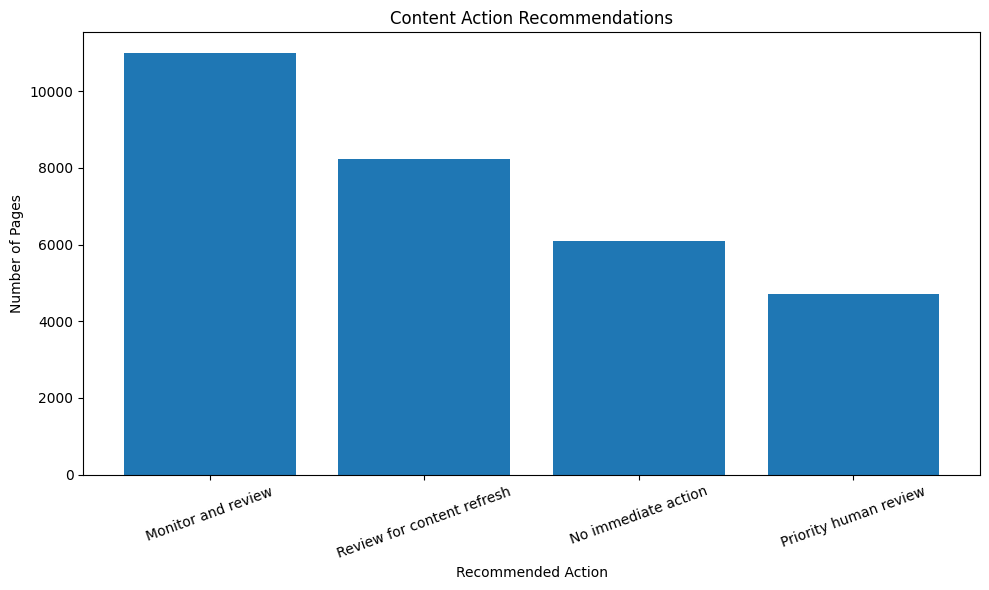


FILES CREATED SUCCESSFULLY
- action_distribution.png
- top_20_content_actions.csv
- content_action_queue.csv
- action_summary.csv
- monitoring_baseline.csv


In [15]:
# ============================================================
# ML-10 SECTION 5 — EXPORTS FOR THE PAPER
# ============================================================

import os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CREATE OUTPUT FOLDER
# ------------------------------------------------------------

output_dir = "work/outputs"

os.makedirs(
    output_dir,
    exist_ok=True
)

print(f"Output folder ready: {output_dir}")


# ------------------------------------------------------------
# 1. EXPORT FULL ACTION QUEUE
# ------------------------------------------------------------

full_queue_path = os.path.join(
    output_dir,
    "content_action_queue.csv"
)

# Remove client_id before export for privacy
safe_action_queue = action_queue.drop(
    columns=["client_id"],
    errors="ignore"
)

safe_action_queue.to_csv(
    full_queue_path,
    index=False
)


# ------------------------------------------------------------
# 2. EXPORT TOP 20 QUEUE
# ------------------------------------------------------------

top_20_path = os.path.join(
    output_dir,
    "top_20_content_actions.csv"
)

top_queue.to_csv(
    top_20_path,
    index=False
)


# ------------------------------------------------------------
# 3. EXPORT ACTION SUMMARY
# ------------------------------------------------------------

summary_path = os.path.join(
    output_dir,
    "action_summary.csv"
)

use_summary.to_csv(
    summary_path,
    index=False
)


# ------------------------------------------------------------
# 4. EXPORT MONITORING BASELINE
# ------------------------------------------------------------

monitoring_path = os.path.join(
    output_dir,
    "monitoring_baseline.csv"
)

baseline_monitoring.to_csv(
    monitoring_path
)


# ------------------------------------------------------------
# 5. CREATE FIGURE
# ------------------------------------------------------------

figure_path = os.path.join(
    output_dir,
    "action_distribution.png"
)

action_counts = (
    action_queue["recommended_action"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    action_counts.index,
    action_counts.values
)

plt.title("Content Action Recommendations")

plt.xlabel("Recommended Action")

plt.ylabel("Number of Pages")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FILES CREATED SUCCESSFULLY")
print("=" * 60)

for filename in os.listdir(output_dir):
    print("-", filename)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.